In [16]:
!pip install nltk -q

import pandas as pd
import nltk
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter


In [17]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [4]:
df = pd.read_csv("archive (7).csv")

In [5]:
print(df.head())

                            Uniq Id            Crawl Timestamp  \
0  10d8b81dc693db8a3f92e19254525d53  2020-03-17 02:32:10 +0000   
1  31ef1ee4961d3fcff33e363edd7677eb  2020-03-17 02:32:10 +0000   
2  6943e517922b051cbec496be32fbb57f  2020-03-17 02:32:10 +0000   
3  6778c794e6ac7112981d4ebb239d6826  2020-03-17 02:32:10 +0000   
4  2335a28ae24db3b2191080bfd98a86e0  2020-03-17 02:32:10 +0000   

                    Billing Uniq Id  Rating  \
0  c697dc43961526785292107b91a639e1     NaN   
1  c697dc43961526785292107b91a639e1     NaN   
2  c697dc43961526785292107b91a639e1     NaN   
3  c697dc43961526785292107b91a639e1     NaN   
4  c697dc43961526785292107b91a639e1     NaN   

                                        Review Title  Review Rating  \
0                           Best Natural Deodorant!!            5.0   
1          Schmidt's Charcoal Deodorant is the best!            5.0   
2                  Beware. Defective or counterfeit.            1.0   
3  Good for infrequent shavers in co

In [18]:
stop_words = set(stopwords.words('english'))

def preprocess(text):

    words = word_tokenize(str(text).lower())

    words = [
        word for word in words
        if word.isalnum() and word not in stop_words
    ]

    return " ".join(words)


df["clean_feedback"] = df["Review Content"].fillna("").apply(preprocess)

In [19]:
sia = SentimentIntensityAnalyzer()


def get_sentiment(text):

    score = sia.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"


df["Sentiment"] = df["clean_feedback"].apply(get_sentiment)


In [20]:
negative_feedback = df[df["Sentiment"] == "Negative"]

In [21]:
print("\nSentiment Summary")

print(df["Sentiment"].value_counts())


Sentiment Summary
Sentiment
Positive    41
Negative     5
Neutral      4
Name: count, dtype: int64


In [22]:
print("\nBusiness Insights")

print("Total Reviews :", len(df))

print("Positive Reviews :",
      len(df[df["Sentiment"] == "Positive"]))

print("Negative Reviews :",
      len(df[df["Sentiment"] == "Negative"]))

print("Neutral Reviews :",
      len(df[df["Sentiment"] == "Neutral"]))


Business Insights
Total Reviews : 50
Positive Reviews : 41
Negative Reviews : 5
Neutral Reviews : 4


In [23]:
print("\nTop Brands with Negative Reviews")

print(negative_feedback["Brand"].value_counts().head())


print("\nTop Categories with Negative Reviews")

print(negative_feedback["Category"].value_counts().head())




Top Brands with Negative Reviews
Brand
Schmidt's Deodorant    5
Name: count, dtype: int64

Top Categories with Negative Reviews
Category
Beauty & Personal Care    5
Name: count, dtype: int64


In [24]:
negative_text = " ".join(negative_feedback["clean_feedback"])

common_problems = Counter(
    negative_text.split()
).most_common(10)


print("\nCommon Problems Mentioned in Negative Reviews")

print(common_problems)



Common Problems Mentioned in Negative Reviews
[('deodorant', 3), ('smell', 3), ('using', 3), ('never', 2), ('like', 2), ('buy', 2), ('amazon', 2), ('honestly', 2), ('bad', 2), ('good', 2)]


In [25]:
df.to_csv(
    "product_feedback_analysis.csv",
    index=False
)


print("\nAnalysis Completed Successfully")




Analysis Completed Successfully


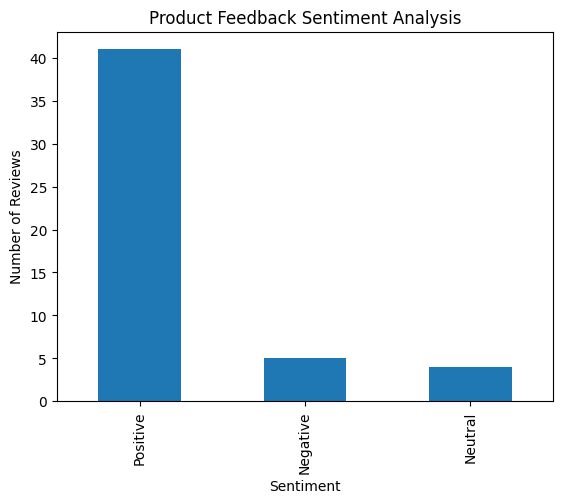

In [28]:


sentiment_count = df["Sentiment"].value_counts()

sentiment_count.plot(
    kind="bar"
)

plt.title("Product Feedback Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()